In [2]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", 
    "pandas", "numpy", "matplotlib", "seaborn", 
    "scikit-learn", "xgboost", "imbalanced-learn", "joblib"])

CompletedProcess(args=['c:\\Users\\priti\\OneDrive\\Desktop\\customer-churn-predictor\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost', 'imbalanced-learn', 'joblib'], returncode=0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/churn_raw.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Churn Count ---")
print(df['Churn'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

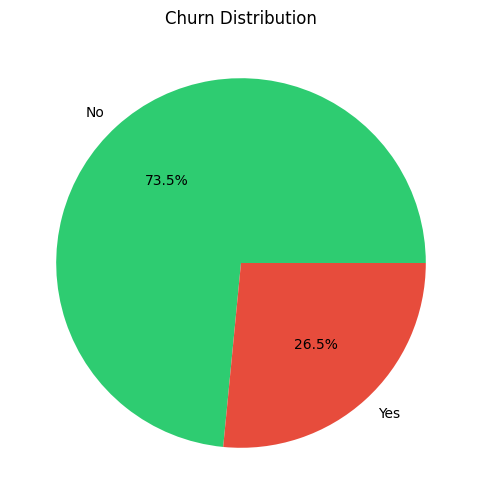

In [5]:
df['Churn'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    figsize=(6,6)
)
plt.title('Churn Distribution')
plt.ylabel('')
plt.savefig('../data/churn_pie.png')
plt.show()

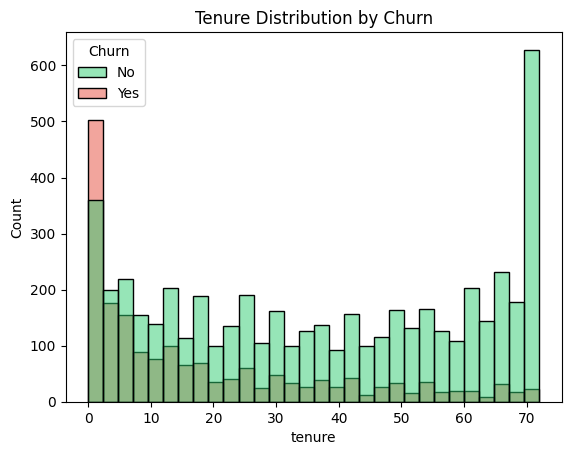

In [6]:
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71','#e74c3c'])
plt.title('Tenure Distribution by Churn')
plt.savefig('../data/tenure_churn.png')
plt.show()

C:\Users\priti\AppData\Local\Temp\ipykernel_26220\2789666137.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges',


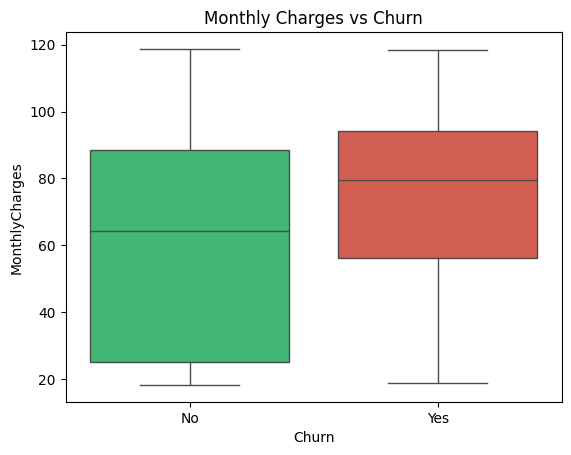

In [7]:
sns.boxplot(x='Churn', y='MonthlyCharges',
            data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges vs Churn')
plt.savefig('../data/charges_churn.png')
plt.show()

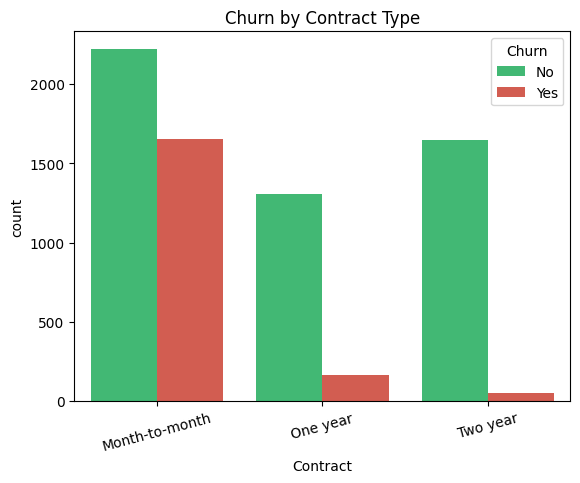

In [8]:
sns.countplot(x='Contract', hue='Churn',
              data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.savefig('../data/contract_churn.png')
plt.show()